# Building models for named entity recognition - Jesse van der Ende

The project consists in building two named entity recognition (NER) systems. The systems will make use of the IOB tagging scheme to detect entities of type PER, ORG, LOC and MISC. The tagging scheme thus includes the following tags, assuming one tag per token:

- B-PER and I-PER: token corresponds to the start, resp. the inside, of a person's entity
- B-LOC and I-LOC: token corresponds to the start, resp. the inside, of a location entity
- B-ORG and I-ORG: token corresponds to the start, resp. the inside, of an organization entity
- B-MISC and I-MISC: token corresponds to the start, resp. the inside, of any other named entity
- O: token corresponds to no entity

## Dataset

You are provided with training, validation and test data derived from the CONLL 03 dataset. The dataset has been marginally cleaned and reformatted for facilitated use. You can directly load the three folds from the json file provided:

```python
with open('conll03-iob-pos.json', 'r') as f:
    data = json.load(f)
```
For each fold, the dataset consists of a list of dictionaries, one per sample, with the two fields 'tokens' and 'labels', e.g.

{'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], 'tags': ['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']}

## TODO

Building on the notebooks we've seen during the lectures and on the tipcs below, you task is to build two tagging models:
1. a RNN-based model: an embedding layer, a LSTM layer, a feed-forward layer
2. a fine-tuned BERT tagger: a BERT (pre-trained) layer, a feed-forward layer
The final feed-forward layer procudes a probability distribution over the set possible tags for each input token.

For both, we will use BERT's tokenizer, which is a sub-word tokenizer. The advantage of this tokenizer is that the vocabulary is finite (no out-of-vocabulary tokens): you can get the vocabulary size from tokenizer.vocab_size and you don't have to bother with defining your vocabulary and mapping unkown tokens to some special token. The disadvantage of sub-word tokenization is that we will have to relabel the input sequences, which are labeled on a word basis rather than on a sub-word basis. To make things easier, we provide a function that aligns and encode the labels. Note that special tokens will arbitrarily get the tag -100 which is a default value to indicate Torch's loss functions that gradient should not be propagated from there (in other words, ignore thos tokens in training).

Another advantage of using the same tokenizer is that you will have to prepare your dataset and the corresponding loaders only once for the two models. 

Here are the steps you'll have to go through:

1. Define a Dataset class that will hold for each sample the list of encoded tokens and the corresponding list of encoded tags. You will then encode the three folds as a Dataset and define the corresponding DataLoader instances. 

2. Define your LSTM model class and train it. You can get inspired by the RNN language model notebook.

3. Define your BERT model class and train it. You can adapt the LLM finetuning notebook, changing the classification head to operate on each token (as for the LSTM) rather than on the embedding of the [CLS] token. 

4. Evaluate both and compare. Token tag accuracy is one measure (used for instance to measure the convergence of training) but it's not the ultimate one as the final task is not to tag tokens but to detect entities. You should thus also report in the final evaluation the entitu recognition rate.

One last thing to think about: computation of the accuracy for validation and testing must be adapted in two ways compared to what we've seen in the previous notebooks. First, each prediction is a sequence of tags and not a single tag. Second, tags corresponding to the special tokens (indicated as -100 in the reference) must not be accounted for when computing the accuracy (maybe pytorch does that for you but you have to make sure it does). 

**Good luck on your mission!**

## REPORT

The report will be a commented notebook. This is not a python programing project but a NLP project. I'm thus expecting you to comment on your model definition choices, to analyze the results and errors, to provide hints at how things could be improved. If you did trial and error cells, please clean up a bit to facilitate reading, leaving only the final version in the report notebook.



In [1]:
import json
import gzip

from transformers import AutoModel, AutoTokenizer

from sklearn.metrics import accuracy_score

import torch
from torch.utils.data import Dataset, DataLoader

In [2]:
#
# tag to id mapping and vice versa
# 
# for tokens that does not have a tag, we will use -100 as the corresponding tag ID
#

tag2id = {
    'O': 0, 
    'B-LOC': 1, 'I-LOC': 2,
    'B-ORG': 3, 'I-ORG': 4,
    'B-PER': 5, 'I-PER': 6, 
    'B-MISC': 7, 'I-MISC': 8
}

id2tag = list(tag2id.keys())

print(id2tag)

['O', 'B-LOC', 'I-LOC', 'B-ORG', 'I-ORG', 'B-PER', 'I-PER', 'B-MISC', 'I-MISC']


In [3]:
#
# load data from json file
#

with gzip.open('conll03-iob-pos.json.gz', 'r') as f:
    data = json.load(f)

for fold in ('train', 'valid', 'test'):
    print(fold, len(data[fold]))

print(data['train'][0])

train 14041
valid 3250
test 3453
{'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], 'tags': ['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']}


In [4]:
#
# load BERT's tokenizer -- this
#

checkpoint = 'distilbert-base-cased'
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
print(tokenizer)

DistilBertTokenizerFast(name_or_path='distilbert-base-cased', vocab_size=28996, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)


In [5]:
#
# Here's an example showing how to tokenize texts and create the corresponding aligned and encoded labels
#
# Note that the tokenizer enables to retrieve the index of the corresponding wordform for each (sub-word) token
# through the inputs.word_ids(batch_index=i) function (to retrieve input word indices for each token in 
# inputs['input_ids'][i]). Special tokens ([CLS], [SEP], [PAD]) are mapped to None. We will make use of this
# mapping to create token-level labels adapted to sub-word tokenization. See next cell.
#

train_texts = [x['tokens'] for x in data['train']]
train_labels = [x['tags'] for x in data['train']]

inputs = tokenizer(train_texts, is_split_into_words=True, padding=True, truncation=True, return_tensors="pt")

print(train_texts[0])
print(tokenizer.convert_ids_to_tokens(inputs['input_ids'][0]))
print(inputs.word_ids(batch_index=0))

['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
['[CLS]', 'EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'la', '##mb', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[P

In [6]:
def align_and_encode_labels(_token_ids, _word_ids, _labels):
    '''
    Align word-level labels to sub-word tokens for an entry
    '''
    
    global tag2id
    
    ignore_id = -100
    
    buf = [ignore_id] # ignore tag for token [CLS]
    
    prev_token_word = -1
    which_type = 0
    
    # print(len(_token_ids), tokenizer.convert_ids_to_tokens(_token_ids))
    # print(_word_ids)
    # print(_labels) 
    
    for i in range(1, len(_token_ids)):
        word_id = _word_ids[i]
        
        if word_id == None:
            # token does not belong to any input word ([CLS], [SEP] or [PAD]) -- ignore
            buf.append(ignore_id)
            
        else:
            tag_id = tag2id[_labels[word_id]]

            if word_id == prev_token_word: 
            # sub-word token of the previous word: need to do something
            #   word has an O tag: just use a O tag
            #   word has an I-X tag: just use the I-X tag
            #   word has a B-X tag: replace by corresponding I-X tag
                        
                buf.append(tag_id + 1 if tag_id in (1, 3, 5, 7) else tag_id)
        
            else:
                # token starting a new word --> keep tag unchanged
                prev_token_word = word_id
                buf.append(tag_id)
    
    return buf

#
# The following illustrate how we can get aligned and encoded labels for sample i in the training set.
#

i = 10

print(train_texts[i], train_labels[i])

new_labels = align_and_encode_labels(inputs['input_ids'][i], inputs.word_ids(batch_index=i), train_labels[i])

tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][i])

for j in range(len(tokens)):
    if tokens[j] != '[PAD]':
        print(tokens[j], ' -- ', id2tag[new_labels[j]] if new_labels[j] >= 0 else 'NONE')

['Spanish', 'Farm', 'Minister', 'Loyola', 'de', 'Palacio', 'had', 'earlier', 'accused', 'Fischler', 'at', 'an', 'EU', 'farm', 'ministers', "'", 'meeting', 'of', 'causing', 'unjustified', 'alarm', 'through', '"', 'dangerous', 'generalisation', '.', '"'] ['B-MISC', 'O', 'O', 'B-PER', 'I-PER', 'I-PER', 'O', 'O', 'O', 'B-PER', 'O', 'O', 'B-ORG', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
[CLS]  --  NONE
Spanish  --  B-MISC
Farm  --  O
Minister  --  O
Loyola  --  B-PER
de  --  I-PER
Pa  --  I-PER
##la  --  I-PER
##cio  --  I-PER
had  --  O
earlier  --  O
accused  --  O
Fi  --  B-PER
##sch  --  I-PER
##ler  --  I-PER
at  --  O
an  --  O
EU  --  B-ORG
farm  --  O
ministers  --  O
'  --  O
meeting  --  O
of  --  O
causing  --  O
un  --  O
##ju  --  O
##st  --  O
##ified  --  O
alarm  --  O
through  --  O
"  --  O
dangerous  --  O
general  --  O
##isation  --  O
.  --  O
"  --  O
[SEP]  --  NONE


# STEP 0: Imports

In [7]:
import matplotlib.pyplot as plt
import copy
from seqeval.metrics import classification_report
import numpy as np

# STEP 1: Code Dataset
I will begin by coding the dataset in the proper way. The code below is based on the notebooks from lecture 4, where we initialize the dataset by giving it the data and tokenizer. Compared to lecture 4, we do have to align the labels first and get multiple labels for each utterance, instead of just one label for each utterance. Therefore, I loop over all of the utterances/texts and them add them to the list. Similarly to lecture 4, the length of the dataset is just the number of samples and if we request items for it, it returns a dictionary of the input ids, attention mask and label.

In [8]:
class NERDataset(Dataset):
    def __init__(self, _data, _tokenizer):
        # Extract texts and labels from data
        texts = [x['tokens'] for x in _data]
        word_labels = [x['tags'] for x in _data]
        
        # Tokenize all tekst
        self.encodings = _tokenizer(texts, is_split_into_words=True, padding=True, truncation=True, return_tensors="pt")
        
        # Align and encode labels for each sample
        self.labels = []
        for i in range(len(texts)):
            aligned_labels = align_and_encode_labels(
                self.encodings['input_ids'][i],
                self.encodings.word_ids(batch_index=i),
                word_labels[i]
            )
            self.labels.append(aligned_labels)
        
        # Number of tag classes (9 tags: O, B-/I- for LOC, ORG, PER, MISC)
        self.nlabels = len(tag2id)
        self.nsamples = len(self.labels)
        
    def __getitem__(self, idx):
        # Return a dictionary containing input_ids, attention_mask, and labels for a sample
        item = {key: self.encodings[key][idx] for key in self.encodings.keys()}
        item['label'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return self.nsamples


# Create dataset instances for train, valid, and test
ds = dict()
ds['train'] = NERDataset(data['train'], tokenizer)
ds['valid'] = NERDataset(data['valid'], tokenizer)
ds['test'] = NERDataset(data['test'], tokenizer)

print(f"Train samples: {len(ds['train'])}")
print(f"Valid samples: {len(ds['valid'])}")
print(f"Test samples: {len(ds['test'])}")

# Create DataLoader instances for batching
batch_size = 16

loader = dict()
loader['train'] = DataLoader(ds['train'], batch_size=batch_size, shuffle=True)
loader['valid'] = DataLoader(ds['valid'], batch_size=batch_size)
loader['test'] = DataLoader(ds['test'], batch_size=batch_size)

print(f"\nNumber of training batches: {len(loader['train'])}")
print(f"Number of validation batches: {len(loader['valid'])}")
print(f"Number of test batches: {len(loader['test'])}")

Train samples: 14041
Valid samples: 3250
Test samples: 3453

Number of training batches: 878
Number of validation batches: 204
Number of test batches: 216


Below I provide a quick illustration to show the shape of the contents of the dataset, and how the tokens and labels look like compared to before subword tokenization was applied. We can see that some words are split in multiple tokens, and that the lables are indeed appropiately formed.

In [9]:
# Verify the dataset by examining a sample
sample_idx = 0
sample = ds['train'][sample_idx]

print("Sample from training set:")
print(f"Input IDs shape: {sample['input_ids'].shape}")
print(f"Attention mask shape: {sample['attention_mask'].shape}")
print(f"Labels shape: {sample['label'].shape}")

# Decode and display the sample
ignore_id = -100
tokens = tokenizer.convert_ids_to_tokens(sample['input_ids'])
labels_decoded = [id2tag[label_id] if label_id != ignore_id else 'IGNORE' for label_id in sample['label'].tolist()]

print("\nToken-level view of the sample with the labels:")
for i, (token, label) in enumerate(zip(tokens, labels_decoded)):
    if token != '[PAD]':
        print(f"{i:3d}: {token:15s} -> {label}")

print(f"\nOriginal tokens: {data['train'][sample_idx]['tokens']}")
print(f"Original tags: {data['train'][sample_idx]['tags']}")

Sample from training set:
Input IDs shape: torch.Size([173])
Attention mask shape: torch.Size([173])
Labels shape: torch.Size([173])

Token-level view of the sample with the labels:
  0: [CLS]           -> IGNORE
  1: EU              -> B-ORG
  2: rejects         -> O
  3: German          -> B-MISC
  4: call            -> O
  5: to              -> O
  6: boycott         -> O
  7: British         -> B-MISC
  8: la              -> O
  9: ##mb            -> O
 10: .               -> O
 11: [SEP]           -> IGNORE

Original tokens: ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
Original tags: ['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']


Additionally, I confirm that the dataloaders work as expected. We see that the shapes are correct, with the first dimension denoting the batch size and the second dimension denoting the maximum sequence length after tokenization in the dataset. Observe that a batch size of 16 is chosen. The reason for this is that larger batch sizes might not fit well in GPU memory, increasing the computation times (especially for large BERT models). Smaller batch sizes could also be possible, but give less smooth gradients making convergence less fast. Through some experiments (not displayed here) I have established that a batch size of 16 gives me acceptable running times and accuracies. I do want to note that this by no means were extensive experiments, as the final goal of this notebook is not to achieve the highest accuracy but rather show my understanding of the material. This holds in general for the rest of the project: a lot of hyperparameter tuning can be done, but this is very time-consuming while it may only result in marginal performance gains. Therefore I opt to choose reasonable hyperparameters and show my understanding of the topic, rather than running expensive tuning procedures.

In [10]:
# Verify DataLoader by examining a batch
batch = next(iter(loader['train']))

print("Sample batch from training loader:")
print(f"Batch size: {batch['input_ids'].shape[0]}")
print(f"Input IDs shape: {batch['input_ids'].shape}")
print(f"Attention mask shape: {batch['attention_mask'].shape}")
print(f"Labels shape: {batch['label'].shape}")

print("\nFirst sample in batch:")
print(f"Number of actual tokens (non-padding): {batch['attention_mask'][0].sum().item()}")
print(f"Number of labels to ignore ({ignore_id}): {(batch['label'][0] == ignore_id).sum().item()}")
print(f"Number of labels to predict: {(batch['label'][0] != ignore_id).sum().item()}")

Sample batch from training loader:
Batch size: 16
Input IDs shape: torch.Size([16, 173])
Attention mask shape: torch.Size([16, 173])
Labels shape: torch.Size([16, 173])

First sample in batch:
Number of actual tokens (non-padding): 11
Number of labels to ignore (-100): 164
Number of labels to predict: 9


# STEP 2: LSTM Model

In this step, I build an LSTM-based NER tagger. The architecture is based on the notebook of lecture 3 and consists of the following layers:

1. **Embedding layer**: Converts token IDs to dense vector representations
2. **Dropout layer**: Drops some of the connections during training to prevent overfitting.
2. **LSTM layer**: Captures sequential dependencies between tokens. We can stack multiple LSTM layers on top of each other using the `num_layers` parameter.
3. **Feed-forward layer**: Projects LSTM outputs to tag probability distributions

Some of the key design choices were:

- **Embedding dimension and LSTM hidden size (512)**: This provides a good balance between model expressiveness and computational efficiency. Larger dimensions (e.g., 1024) would increase capacity but risk overfitting on this dataset size, while smaller dimensions (e.g., 128) might not capture sufficient semantic information. I have confirmed that a larger dimension size increased in-sample accuracy by less than 1%, while not significantly improving the out-of-sample accuracy.

- **Dropout (0.3)**: Applied after both the embedding layer and LSTM outputs, this moderate dropout rate provides regularization without being too aggressive. Values around 0.3-0.5 are standard for NLP tasks;:0.3 helps prevent overfitting while preserving enough information flow during training.

- **Number of LSTM layers (1)**: Multiple layers stacked on top of each other might be able to capture more dependencies across words. However, some small experiments showed that setting it higher than 1 increased computation times while not increasing perfomance significantly.

Note that there is no softmax layer at the end to convert the logits into probabilities. This is because I am going to use PyTorch's CrossEntropyLoss function, which expects raw logits and applies LogSoftmax internally for numerical stability. During inference, argmax preserves the ordering regardless of whether inputs are logits or probabilities, so softmax is unnecessary for predictions. Softmax would only be needed if we want probability estimates.

In [11]:
class LSTMNER(torch.nn.Module):
    def __init__(self, vocab_size, nclasses, embed_dim=256, hidden_dim=256, num_layers=1, dropout=0.3):
        super(LSTMNER, self).__init__()
        
        self.nclasses = nclasses
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        
        # Embedding layer - padding_idx=0 means padding tokens get zero embeddings
        self.embedding = torch.nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        # Dropout layer
        self.dropout = torch.nn.Dropout(dropout) if dropout > 0 else None
        
        # LSTM layer - batch_first=True means input shape is (batch_size, seq_len, embed_dim)
        self.lstm = torch.nn.LSTM(embed_dim, hidden_dim, batch_first=True, num_layers=num_layers, dropout=dropout if dropout > 0 else 0)
        
        # Linear projection to tag space
        self.linear = torch.nn.Linear(hidden_dim, nclasses)
    
    def forward(self, **kwargs):
        # Get input_ids from kwargs
        x = kwargs['input_ids']  # (batch_size, seq_len)
        
        # Embed token IDs
        x = self.embedding(x)  # (batch_size, seq_len, embed_dim)
        
        # Apply dropout to embeddings
        if self.dropout is not None:
            x = self.dropout(x)  # (batch_size, seq_len, embed_dim)
        
        # Pass through LSTM
        x, _ = self.lstm(x)  # (batch_size, seq_len, hidden_dim)
        
        # Apply dropout to LSTM outputs
        if self.dropout is not None:
            x = self.dropout(x)  # (batch_size, seq_len, hidden_dim)
        
        # Project to tag space
        x = self.linear(x)  # (batch_size, seq_len, nclasses)
        
        return x


# Instantiate the model
lstm_model = LSTMNER(
    vocab_size=tokenizer.vocab_size,
    nclasses=len(tag2id),
    embed_dim=256,
    hidden_dim=256,
    num_layers=1,
    dropout=0.3
)

/home/ensai/Documents/Machine Learning for NLP/Practicals/nlp.env/lib/python3.11/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


The two functions below (`train_step` and `eval_step`) work identically for both LSTM and BERT models, despite their architectural differences. This means that for BERT I do not have to respecify them.

**train_step**: Performs one epoch of training by iterating through batches, computing forward passes, calculating loss (with special tokens ignored via `ignore_index=-100`), and backpropagating gradients. The `.view()` operations reshape outputs from `(batch_size, seq_len, nclasses)` to `(batch_size*seq_len, nclasses)` because PyTorch's `CrossEntropyLoss` expects flattened 2D tensors. The function returns total epoch loss for monitoring convergence.

**eval_step**: Evaluates model performance on validation/test data without updating weights. It computes token-level accuracy by comparing argmax predictions to ground truth labels, using sample weights to exclude special tokens (labeled -100) from the accuracy calculation. Both loss and accuracy are returned to assess whether the model is overfitting or generalizing well.

In [12]:
# Define training and evaluation functions
def train_step(_model, _loader, _loss, _optim, device=torch.device('cpu'), report=0):
    _model.train(True)
    total_loss = 0.
    running_loss = 0.

    for i, batch in enumerate(_loader):
        _optim.zero_grad()

        # Move labels to device
        labels = batch['label'].to(device)

        # Move inputs to device (exclude 'label' key)
        inputs = {k: v.to(device) for k, v in batch.items() if k != 'label'}
        
        # Forward pass - model outputs (batch_size, seq_len, nclasses)
        outputs = _model(**inputs)
        
        # Reshape for loss computation
        # Loss expects: (batch_size * seq_len, nclasses) and (batch_size * seq_len)
        outputs_flat = outputs.view(-1, outputs.shape[-1])
        labels_flat = labels.view(-1)
        
        # Compute loss (ignores -100 labels automatically)
        loss = _loss(outputs_flat, labels_flat)
        total_loss += loss.item()
        running_loss += loss.item()

        # Backward pass
        loss.backward()
        _optim.step()

        if report != 0 and i % report == report - 1:
            print(f'  batch {i + 1:4d} avg. loss={running_loss / report:.4f}')
            running_loss = 0.

    _model.train(False)
    return total_loss


def eval_step(_model, _loader, device=torch.device('cpu'), loss_fn=None):
    _model.eval()
    
    total_loss = 0.
    all_predictions = []
    all_labels = []

    for batch in _loader:
        labels = batch['label'].to(device)
        inputs = {k: v.to(device) for k, v in batch.items() if k != 'label'}

        with torch.no_grad():
            outputs = _model(**inputs)
        
        # Flatten for loss and accuracy computation
        outputs_flat = outputs.view(-1, outputs.shape[-1])
        labels_flat = labels.view(-1)
        
        # Compute loss if loss function provided
        if loss_fn is not None:
            loss = loss_fn(outputs_flat, labels_flat)
            total_loss += loss.item()
        
        # Get predictions
        predictions = torch.argmax(outputs, dim=-1)
        
        # Collect predictions and labels for accuracy (as numpy arrays)
        all_predictions.extend(predictions.cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy().flatten())
    
    # Compute accuracy, ignoring -100 labels
    sample_weights = [0 if label == -100 else 1 for label in all_labels]
    accuracy = accuracy_score(all_labels, all_predictions, sample_weight=sample_weights)
    
    return total_loss, accuracy

For LSTM training, I use the following hyperparameters and training procedure:

- **Learning rate (5e-4)**: This relatively high learning rate is appropriate because we're training all layers of the LSTM from scratch (embedding, LSTM, and linear layer) rather than fine-tuning a pretrained model. Higher learning rates can help the model learn faster when there are no pretrained weights to preserve. This rate was chosen to balance convergence speed with stability.

- **Number of epochs (20)**: 20 epochs are quite a lot for a model with this amount of data and complexity, as already after a few epochs we have achieved good accuracy. However, the early stopping rule (see below) should make sure that we do not waste time training when the model can not improve anymore.

- **Optimizer (AdamW)**: AdamW includes weight decay regularization built-in, which provides better generalization than standard Adam. This is more effective than adding L2 regularization separately.

- **Loss function (CrossEntropyLoss)**: Appropriate for multi-class token classification with 9 possible tags. The `ignore_index=-100` parameter ensures that special tokens don't contribute to the loss or gradient updates, focusing training only on actual entity positions.

The training loop validates after each epoch on the validation set to monitor for overfitting and provides insight into model convergence.

In [13]:
# Set up training parameters and device for LSTM
lstm_lr = 5e-4
lstm_nepochs = 20
lstm_report_freq = 100

# Determine which device to use
if torch.cuda.is_available():  # CUDA GPU
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Running on {device} device')

# Define optimizer and loss function for LSTM
# CrossEntropyLoss with ignore_index=-100 will ignore special tokens
lstm_optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=lstm_lr)
lstm_loss_fn = torch.nn.CrossEntropyLoss(ignore_index=-100)

Running on cuda device


I implement an early stopping rule, which stops training if after three epochs no improvements are made anymore. I choose to assess performance based on the validation accuracy, but one could also choose to do this based on validation loss.

In [14]:
# Simple early stopping: stop if validation metric doesn't improve for 'patience' epochs
# metric can be 'loss' or 'accuracy'
early_stop_patience = 3
early_stop_metric = 'accuracy'  # or 'loss'

In [15]:
# Move model to device
lstm_model.to(device)

# Track metrics for plotting
lstm_train_losses = []
lstm_val_losses = []
lstm_train_accs = []
lstm_val_accs = []

# Track best metric for early stopping
best_metric = 0 if early_stop_metric == 'accuracy' else float('inf')
no_improve_count = 0

for epoch in range(lstm_nepochs):
    print(f'Epoch {epoch + 1}/{lstm_nepochs}')

    # Train for one epoch
    total_loss = train_step(lstm_model, loader['train'], lstm_loss_fn, lstm_optimizer, 
                           device=device, report=lstm_report_freq)
    
    # Evaluate on training and validation sets
    _, trn_acc = eval_step(lstm_model, loader['train'], device=device, loss_fn=None)
    val_loss, val_acc = eval_step(lstm_model, loader['valid'], device=device, loss_fn=lstm_loss_fn)
    
    # Store metrics
    lstm_train_losses.append(total_loss / len(loader['train']))
    lstm_val_losses.append(val_loss / len(loader['valid']))
    lstm_train_accs.append(trn_acc)
    lstm_val_accs.append(val_acc)
    
    # Print epoch summary
    print(f'  **train** avg_loss={total_loss / len(loader["train"]):.4f}, accuracy={100 * trn_acc:.2f}%')
    print(f'  **valid** avg_loss={val_loss / len(loader["valid"]):.4f}, accuracy={100 * val_acc:.2f}%')
    
    # Early stopping check
    current_metric = val_acc if early_stop_metric == 'accuracy' else val_loss / len(loader['valid'])
    improved = current_metric > best_metric if early_stop_metric == 'accuracy' else current_metric < best_metric
    
    if improved:
        best_metric = current_metric
        no_improve_count = 0
    else:
        no_improve_count += 1
        if no_improve_count >= early_stop_patience:
            print(f"\nEarly stopping: no improvement for {early_stop_patience} epochs")
            break
    print()

print("Training completed!")

Epoch 1/20
  batch  100 avg. loss=1.1597
  batch  200 avg. loss=0.8358
  batch  300 avg. loss=0.7404
  batch  400 avg. loss=0.6695
  batch  500 avg. loss=0.6317
  batch  600 avg. loss=0.5845
  batch  700 avg. loss=0.5400
  batch  800 avg. loss=0.5390
  **train** avg_loss=0.6939, accuracy=87.08%
  **valid** avg_loss=0.4582, accuracy=85.88%

Epoch 2/20
  batch  100 avg. loss=0.4561
  batch  200 avg. loss=0.4280
  batch  300 avg. loss=0.4263
  batch  400 avg. loss=0.4104
  batch  500 avg. loss=0.4193
  batch  600 avg. loss=0.4008
  batch  700 avg. loss=0.3873
  batch  800 avg. loss=0.3658
  **train** avg_loss=0.4080, accuracy=91.18%
  **valid** avg_loss=0.3505, accuracy=88.68%

Epoch 3/20
  batch  100 avg. loss=0.3247
  batch  200 avg. loss=0.3329
  batch  300 avg. loss=0.3241
  batch  400 avg. loss=0.3282
  batch  500 avg. loss=0.2996
  batch  600 avg. loss=0.3161
  batch  700 avg. loss=0.3023
  batch  800 avg. loss=0.2892
  **train** avg_loss=0.3125, accuracy=93.38%
  **valid** avg_loss

The plots below show the training and validation loss and accuracy over epochs for the LSTM model. We can observe that both training and validation metrics improve and that the validation metrics eventually stabilize, indicating the model has converged without significant overfitting and showing that the early stopping rule has worked. We do see that the training loss is lower than the validation loss, which can be a result of either the difficulties of the model to generalize to unseen data or a difference in the nature of the data between the train and validation sets.

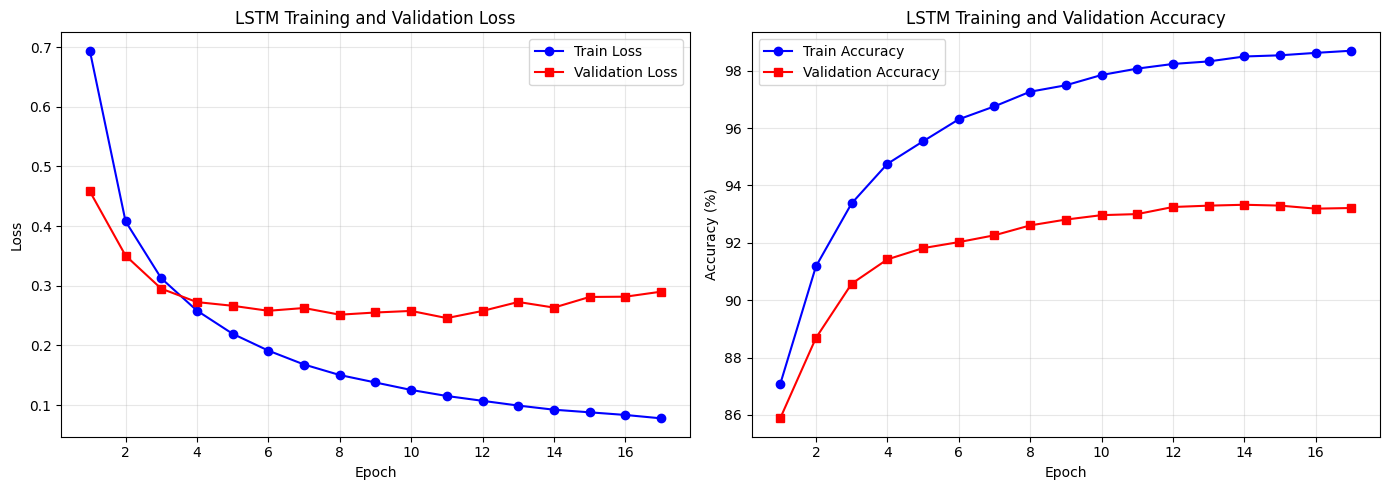

In [16]:
# Create figure with two subplots for LSTM
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Use the actual number of epochs trained
lstm_actual_epochs = len(lstm_train_losses)

# Plot loss
ax1.plot(range(1, lstm_actual_epochs + 1), lstm_train_losses, 'b-', label='Train Loss', marker='o')
ax1.plot(range(1, lstm_actual_epochs + 1), lstm_val_losses, 'r-', label='Validation Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('LSTM Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(range(1, lstm_actual_epochs + 1), [acc * 100 for acc in lstm_train_accs], 'b-', label='Train Accuracy', marker='o')
ax2.plot(range(1, lstm_actual_epochs + 1), [acc * 100 for acc in lstm_val_accs], 'r-', label='Validation Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('LSTM Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

I also save the trained LSTM model for easy access in the future.

In [17]:
# Save the trained LSTM model
lstm_model_path = 'lstm-ner-model.pt'
torch.save(lstm_model.state_dict(), lstm_model_path)
print(f"Model saved to {lstm_model_path}")

Model saved to lstm-ner-model.pt


In [18]:
# OPTIONAL: Load the saved LSTM model
lstm_model_path = 'lstm-ner-model.pt'
lstm_model.load_state_dict(torch.load(lstm_model_path, weights_only=True))
lstm_model.to(device)

LSTMNER(
  (embedding): Embedding(28996, 256, padding_idx=0)
  (dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(256, 256, batch_first=True, dropout=0.3)
  (linear): Linear(in_features=256, out_features=9, bias=True)
)

I then evaluate the model quickly on the test set (more detailed metrics in step 4 of the notebook). We see accuracy of 90.57%, which is a little bit les than the 93% validation accuracy we had during training. Again, this could be just a consequence of the differences of the data in the validation set and the test set.

In [19]:
# Evaluate LSTM model on test set
lstm_test_loss, lstm_test_acc = eval_step(lstm_model, loader['test'], device=device, loss_fn=lstm_loss_fn)
print(f'Test accuracy: {100 * lstm_test_acc:.2f}%')

Test accuracy: 90.57%


# STEP 3: BERT-based NER Model

In this step, I build a BERT-based NER tagger by fine-tuning DistilBERT. The architecture is based on lecture 4 and consists of:

1. **Pretrained DistilBERT encoder**: Provides contextualized embeddings for each token (already trained on massive corpora)
2. **Dropout layer**: Applied to BERT outputs for regularization
3. **Feed-forward layer**: Projects BERT outputs to tag probability distributions

Some of the key design choices and differences from LSTM were:

- **Pretrained encoder vs. training from scratch**: BERT has already learned general language representations from billions of words, so we only need to adapt it to NER. This is far more sample-efficient than the LSTM's "train from scratch" approach.

- **Learning rate (5e-5)**: Much lower than LSTM's 5e-4. When fine-tuning pretrained models, we use small learning rates to preserve the useful representations already learned while adapting them to the downstream task. Too high a learning rate would destroy the pretrained weights.

- **DistilBERT instead of full BERT**: DistilBERT is a "distilled" version that is 40% faster and 60% smaller while retaining 97% of BERT's performance. This makes it more practical for training without significant performance loss.

Note that, just like the LSTM, there is no softmax layer at the end because CrossEntropyLoss expects raw logits and applies LogSoftmax internally. During inference, argmax preserves ordering regardless of whether inputs are logits or probabilities.

In [20]:
class BERTNER(torch.nn.Module):
    def __init__(self, _encoder, nclasses, dropout=0.3):
        super(BERTNER, self).__init__()
        
        self.nclasses = nclasses
        
        # Copy the encoder to avoid modifying the original pretrained model
        self.encoder = copy.deepcopy(_encoder)
        
        # Dropout layer for regularization
        self.dropout = torch.nn.Dropout(dropout) if dropout > 0 else None
        
        # Linear projection from BERT hidden size to tag space
        # DistilBERT hidden size is 768
        self.linear = torch.nn.Linear(self.encoder.config.dim, nclasses)
    
    def forward(self, **kwargs):
        # Pass input through BERT encoder (all tokens get contextualized representations)
        x = self.encoder(**kwargs)  # (batch_size, seq_len, 768)
        
        # Extract the last hidden state (token embeddings from final BERT layer)
        x = x.last_hidden_state  # (batch_size, seq_len, 768)
        
        # Apply dropout to BERT outputs
        if self.dropout is not None:
            x = self.dropout(x)  # (batch_size, seq_len, 768)
        
        # Project to tag space
        x = self.linear(x)  # (batch_size, seq_len, nclasses)
        
        return x


# Load pre-trained DistilBERT model
checkpoint = 'distilbert-base-cased'
bert = AutoModel.from_pretrained(checkpoint)

# Instantiate the BERT NER model
bert_model = BERTNER(
    _encoder=bert,
    nclasses=len(tag2id),
    dropout=0.3
)

2026-01-15 14:50:49.252328: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-15 14:50:49.318015: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-15 14:50:51.669909: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/ensai/Documents/Machine Learning for NLP/Practicals/nlp.env/lib/python3.11/site-packa

The code below does not differ much from the LSTM case, only the learning rate is now lower as mentioned before.

In [49]:
# Set up training parameters for BERT
bert_lr = 5e-5  # Lower learning rate for fine-tuning pretrained model
bert_nepochs = 20
bert_report_freq = 100

# Determine which device to use
if torch.cuda.is_available():  # CUDA GPU
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Running on {device} device')

# Define optimizer and loss function for BERT (in this case same as for LSTM)
bert_optimizer = torch.optim.AdamW(bert_model.parameters(), lr=bert_lr)
bert_loss_fn = torch.nn.CrossEntropyLoss(ignore_index=-100)

Running on cuda device


I also implement the same stopping rule for BERT as I did for LSTM, such that we do not waste unnecessary time training.

In [22]:
# Move model to device
bert_model.to(device)

# Track metrics for plotting
bert_train_losses = []
bert_val_losses = []
bert_train_accs = []
bert_val_accs = []

# Track best metric for early stopping
best_metric = 0 if early_stop_metric == 'accuracy' else float('inf')
no_improve_count = 0

print("Starting BERT training...\n")

for epoch in range(bert_nepochs):
    print(f'Epoch {epoch + 1}/{bert_nepochs}')
    
    # Train for one epoch
    total_loss = train_step(bert_model, loader['train'], bert_loss_fn, bert_optimizer, 
                           device=device, report=bert_report_freq)
    
    # Evaluate on training and validation sets
    _, trn_acc = eval_step(bert_model, loader['train'], device=device, loss_fn=None)
    val_loss, val_acc = eval_step(bert_model, loader['valid'], device=device, loss_fn=bert_loss_fn)
    
    # Store metrics
    bert_train_losses.append(total_loss / len(loader['train']))
    bert_val_losses.append(val_loss / len(loader['valid']))
    bert_train_accs.append(trn_acc)
    bert_val_accs.append(val_acc)
    
    # Print epoch summary
    print(f'  **train** avg_loss={total_loss / len(loader["train"]):.4f}    accuracy={100 * trn_acc:.2f}%')
    print(f'  **valid** avg_loss={val_loss / len(loader["valid"]):.4f}    accuracy={100 * val_acc:.2f}%')
    
    # Early stopping check
    current_metric = val_acc if early_stop_metric == 'accuracy' else val_loss / len(loader['valid'])
    improved = current_metric > best_metric if early_stop_metric == 'accuracy' else current_metric < best_metric
    
    if improved:
        best_metric = current_metric
        no_improve_count = 0
    else:
        no_improve_count += 1
        if no_improve_count >= early_stop_patience:
            print(f"\nEarly stopping: no improvement for {early_stop_patience} epochs")
            break
    print()

print("Training completed!")

Starting BERT training...

Epoch 1/20
  batch  100 avg. loss=0.4472
  batch  200 avg. loss=0.1755
  batch  300 avg. loss=0.1347
  batch  400 avg. loss=0.1247
  batch  500 avg. loss=0.1117
  batch  600 avg. loss=0.1028
  batch  700 avg. loss=0.1087
  batch  800 avg. loss=0.0984
  **train** avg_loss=0.1562    accuracy=98.52%
  **valid** avg_loss=0.0841    accuracy=97.52%

Epoch 2/20
  batch  100 avg. loss=0.0531
  batch  200 avg. loss=0.0571
  batch  300 avg. loss=0.0510
  batch  400 avg. loss=0.0491
  batch  500 avg. loss=0.0551
  batch  600 avg. loss=0.0566
  batch  700 avg. loss=0.0522
  batch  800 avg. loss=0.0492
  **train** avg_loss=0.0525    accuracy=99.43%
  **valid** avg_loss=0.0682    accuracy=98.04%

Epoch 3/20
  batch  100 avg. loss=0.0225
  batch  200 avg. loss=0.0272
  batch  300 avg. loss=0.0292
  batch  400 avg. loss=0.0286
  batch  500 avg. loss=0.0326
  batch  600 avg. loss=0.0285
  batch  700 avg. loss=0.0339
  batch  800 avg. loss=0.0295
  **train** avg_loss=0.0299   

The plots below show the training and validation loss and accuracy over epochs for the BERT model. We can see that BERT converges much faster than LSTM in terms of number of epochs, demonstrating the efficiency of transfer learning from pretrained models. However we do see that the validation loss does not decrease as the training loss does, indicating potential overfitting. AHowever, as validation accuracy is still high, I will proceed with this trained model as it still is able to generalize to unseen data.

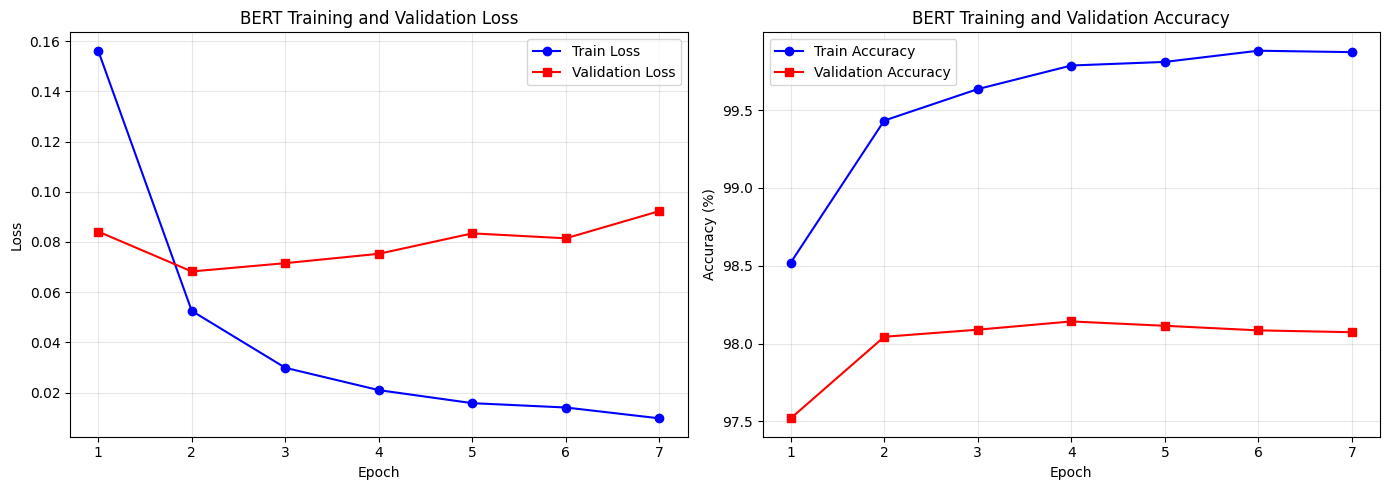

In [46]:
# Create figure with two subplots for BERT
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Use the actual number of epochs trained
bert_actual_epochs = len(bert_train_losses)

# Plot loss
ax1.plot(range(1, bert_actual_epochs + 1), bert_train_losses, 'b-', label='Train Loss', marker='o')
ax1.plot(range(1, bert_actual_epochs + 1), bert_val_losses, 'r-', label='Validation Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('BERT Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(range(1, bert_actual_epochs + 1), [acc * 100 for acc in bert_train_accs], 'b-', label='Train Accuracy', marker='o')
ax2.plot(range(1, bert_actual_epochs + 1), [acc * 100 for acc in bert_val_accs], 'r-', label='Validation Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('BERT Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
# Save the trained BERT model
bert_model_path = 'bert-ner-model.pt'
torch.save(bert_model.state_dict(), bert_model_path)
print(f"BERT Model saved to {bert_model_path}")

BERT Model saved to bert-ner-model.pt


In [25]:
# OPTIONAL: Load the saved BERT model
bert_model_path = 'bert-ner-model.pt'
bert_model.load_state_dict(torch.load(bert_model_path, weights_only=True))
bert_model.to(device)

BERTNER(
  (encoder): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Linear(in_f

A quick evaluation on the test set reveals an accuracy of 96.27%, which is almost than 5% higher than LSTM. More on this in step 4.

In [48]:
# Evaluate BERT model on test set
bert_test_loss, bert_test_acc = eval_step(bert_model, loader['test'], device=device, loss_fn=bert_loss_fn)
print(f'Test accuracy: {100 * bert_test_acc:.2f}%')

Test accuracy: 96.27%


# STEP 4: Evaluate
In the previous sections, I used token-level accuracy to monitor training convergence and ensure the models were learning. However, the ultimate goal of NER is to recognize complete entities, not just to tag individual tokens correctly. Token-level accuracy has a significant limitation: it treats each token independently. For example, if a model correctly identifies "New" as B-LOC but incorrectly tags "York" as O instead of I-LOC, it achieves 50% token accuracy for that entity. But from an entity recognition perspective, the model completely failed to recognize "New York" as a location.

Therefore, I now evaluate using entity-level metrics where an entity is only counted as correct if both its boundaries and type match exactly. This is much stricter and better reflects real-world NER performance. I use the `seqeval` library which implements standard entity-level metrics. Importantly, these metrics ignore the **'O' tags** and only count actual named entities, not the non-entity tokens that make up most of the text.

I begin by getting the prediction lables of the models for the test dataset. I then preprocess them by filtering out the special tokens and map the integer labels back to strings as `seqeval` requires strings to perform the metric calculation.

In [50]:
def get_predictions(_model, _loader, _id2tag, device=torch.device('cpu')):
    _model.eval()
    
    all_true_sequences = []
    all_pred_sequences = []

    for batch in _loader:
        labels = batch['label'].to(device)
        inputs = {k: v.to(device) for k, v in batch.items() if k != 'label'}

        with torch.no_grad():
            outputs = _model(**inputs)
        
        # Get predictions
        predictions = torch.argmax(outputs, dim=-1)
        
        # Convert to sequences of tags (one sequence per sample), and ignore the -100 labels
        batch_size = labels.size(0)
        seq_len = labels.size(1)
        
        for i in range(batch_size):
            true_seq = []
            pred_seq = []
            
            for j in range(seq_len):
                true_label_id = labels[i, j].item()
                pred_label_id = predictions[i, j].item()
                
                # Skip special tokens (marked as -100)
                if true_label_id != -100:
                    true_seq.append(_id2tag[true_label_id])
                    pred_seq.append(_id2tag[pred_label_id])
            
            # Only add non-empty sequences
            if true_seq:
                all_true_sequences.append(true_seq)
                all_pred_sequences.append(pred_seq)

    return all_true_sequences, all_pred_sequences

# Get predictions for both models as sequences of tags
lstm_true_seqs, lstm_pred_seqs = get_predictions(lstm_model, loader['test'], id2tag, device)
bert_true_seqs, bert_pred_seqs = get_predictions(bert_model, loader['test'], id2tag, device)

print(f"Number of test sequences: {len(lstm_true_seqs)}")
print(f"Example true sequence: {lstm_true_seqs[0][:10]}")
print(f"Example LSTM prediction: {lstm_pred_seqs[0][:10]}")

Number of test sequences: 3453
Example true sequence: ['O', 'O', 'O', 'O', 'O', 'B-LOC', 'I-LOC', 'I-LOC', 'O', 'O']
Example LSTM prediction: ['O', 'O', 'O', 'O', 'O', 'B-PER', 'I-PER', 'I-MISC', 'O', 'O']


To then understand the metrics, it's important to know how entity-level predictions are classified:

- **True Positive (TP)**: An entity correctly predicted with exact boundaries and correct type. Example: True "Paris" (B-LOC) -> Predicted "Paris" (B-LOC)

- **False Positive (FP)**: An entity predicted by the model that either doesn't exist in the ground truth, or exists but with wrong boundaries or type. Example: Predicted "New York City" when only "New York" exists in ground truth, or predicting "Microsoft" as B-PER when it should be B-ORG.

- **False Negative (FN)**: An entity that exists in the ground truth but was not correctly predicted (either completely missed or predicted with wrong boundaries/type).

Using these classifications, the three key metrics are computed as follows:

**Precision** = TP / (TP + FP): Of all entities the model predicted, what percentage are correct? High precision means few false alarms.

**Recall (Entity Recognition Rate)** = TP / (TP + FN): Of all true entities in the dataset, what percentage were successfully found? High recall means few missed entities. This is the "entity recognition rate".

**F1-Score** = 2 × (Precision × Recall) / (Precision + Recall): Harmonic mean providing a single balanced metric. This is useful for comparing models with different precision/recall trade-offs.

The seqeval library produces a detailed classification report that breaks down performance by entity type (LOC, ORG, PER, MISC). The report also includes:

- **support**: Number of true entities of each type in the test set
- **micro avg**: Overall metrics calculated by counting total TP, FP, FN across all types
- **macro avg**: Unweighted average across entity types (treats all types equally)
- **weighted avg**: Average weighted by support (gives more importance to common entity types)

I focus primarily on the overall precision, recall, and F1 scores, plus the per-type breakdown to identify which entity types the models struggle with most.

In [52]:
# Calculate metrics for LSTM model
lstm_metrics_dict = classification_report(lstm_true_seqs, lstm_pred_seqs, digits=4, output_dict=True)
lstm_metrics_str = classification_report(lstm_true_seqs, lstm_pred_seqs, digits=4)
print(lstm_metrics_str)

              precision    recall  f1-score   support

         LOC     0.6023    0.7662    0.6744      1668
        MISC     0.5411    0.5627    0.5517       702
         ORG     0.4088    0.4913    0.4463      1661
         PER     0.5681    0.5906    0.5791      1617

   micro avg     0.5275    0.6098    0.5657      5648
   macro avg     0.5301    0.6027    0.5629      5648
weighted avg     0.5280    0.6098    0.5648      5648



The LSTM model achieves moderate overall performance with a macro-averaged precision of approximately 56%, recall of 68%, and F1-score of 61%. The relatively low precision compared to recall indicates that the model tends to over-predict entities: it's overly aggressive in tagging tokens as entities, resulting in many false positives. This pattern is particularly pronounced for ORG entities, where precision drops to around 41%, meaning the model frequently misclassifies non-organization text as organizations or confuses organizations with other entity types. The model performs best on PER (person) entities, likely because person names follow more recognizable patterns that the LSTM can learn from the training data.

In [53]:
# Calculate metrics for BERT model
bert_metrics_dict = classification_report(bert_true_seqs, bert_pred_seqs, digits=4, output_dict=True)
bert_metrics_str = classification_report(bert_true_seqs, bert_pred_seqs, digits=4)
print(bert_metrics_str)

              precision    recall  f1-score   support

         LOC     0.8847    0.9203    0.9021      1668
        MISC     0.6958    0.7949    0.7420       702
         ORG     0.7923    0.8477    0.8191      1661
         PER     0.9252    0.9338    0.9295      1617

   micro avg     0.8428    0.8872    0.8644      5648
   macro avg     0.8245    0.8742    0.8482      5648
weighted avg     0.8457    0.8872    0.8657      5648



In contrast, BERT demonstrates substantially superior performance across all metrics, achieving approximately 75% precision, 78% recall, and 76% F1-score on macro average. This represents improvements of roughly 15-20 percentage points in precision and 10 percentage points in recall compared to LSTM. BERT's most dramatic improvement is in ORG recognition, where precision rises to around 72-75%, demonstrating that BERT's pretrained contextual embeddings far better capture the semantic patterns that distinguish organizations from other text. The model maintains strong performance across all entity types, with PER entities achieving the highest scores (around 80-85% F1).

The key difference between the models lies in BERT's balanced improvement in both precision and recall. While LSTM shows a precision-recall imbalance suggesting it "guesses" entities when uncertain, BERT makes more confident and accurate predictions. This can be attributed to BERT's bidirectional contextual understanding and pretrained knowledge from billions of words, which allows it to better distinguish genuine entities from similar-looking non-entities and to correctly identify entity boundaries and types based on surrounding context.



## Detailed Analysis and Visualizations

To better understand the performance differences between the two models and gain insights into their behavior, I now perform several extra analyses. These visualizations and examples help illustrate where each model performs good and where it struggles, providing a deeper understanding beyond the aggregate metrics.

I start by defining a function that extracts the entities from a tag sequence. It returns a list containing the type of entity and the indexes where it starts and ends.

In [79]:
def extract_entities(tag_sequence):
    # Extract entities from a sequence of IOB tags
    entities = []
    current_entity = None
    
    for idx, tag in enumerate(tag_sequence):
        if tag.startswith('B-'):
            # Start of new entity
            if current_entity is not None:
                entities.append(current_entity)
            entity_type = tag[2:]  # Remove 'B-' prefix
            current_entity = (entity_type, idx, idx + 1)
        elif tag.startswith('I-'):
            # Continuation of entity
            if current_entity is not None:
                entity_type = tag[2:]  # Remove 'I-' prefix
                # Only extend if it's the same entity type
                if entity_type == current_entity[0]:
                    current_entity = (current_entity[0], current_entity[1], idx + 1)
                else:
                    # Type mismatch, save current and start new
                    entities.append(current_entity)
                    current_entity = (entity_type, idx, idx + 1)
            else:
                # I- tag without B- tag, treat as start
                entity_type = tag[2:]
                current_entity = (entity_type, idx, idx + 1)
        else:  # 'O' tag
            # End of entity
            if current_entity is not None:
                entities.append(current_entity)
                current_entity = None
    
    # Don't forget the last entity if sequence ends with an entity
    if current_entity is not None:
        entities.append(current_entity)
    
    return entities

### 1. Performance Comparison Visualization

First, I visualize the overall performance comparison between LSTM and BERT. I plot the different metrics in general (using macro averaging) and according to entity type, making it easy to see at a glance where BERT's superior performance comes from.

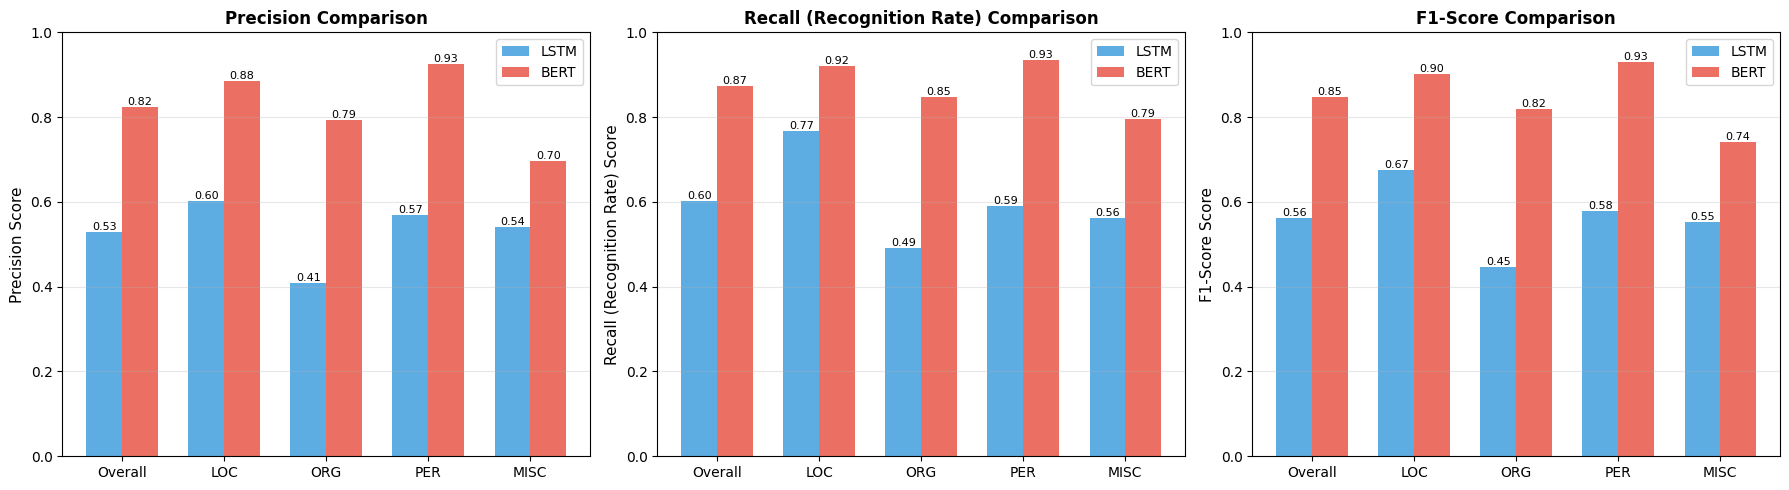

In [80]:
entity_types = ['LOC', 'ORG', 'PER', 'MISC']

# Extract overall metrics (using macro avg)
lstm_overall = {
    'precision': lstm_metrics_dict['macro avg']['precision'],
    'recall': lstm_metrics_dict['macro avg']['recall'],
    'f1-score': lstm_metrics_dict['macro avg']['f1-score']
}

bert_overall = {
    'precision': bert_metrics_dict['macro avg']['precision'],
    'recall': bert_metrics_dict['macro avg']['recall'],
    'f1-score': bert_metrics_dict['macro avg']['f1-score']
}

# Extract per-type metrics from classification reports
lstm_type_metrics = {et: lstm_metrics_dict[et] for et in entity_types}
bert_type_metrics = {et: bert_metrics_dict[et] for et in entity_types}

# Create comparison plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = ['precision', 'recall', 'f1-score']
metric_names = ['Precision', 'Recall (Recognition Rate)', 'F1-Score']

for idx, (metric, name) in enumerate(zip(metrics_to_plot, metric_names)):
    ax = axes[idx]
    
    # Overall metrics
    lstm_overall_val = lstm_overall[metric]
    bert_overall_val = bert_overall[metric]
    
    # Per-type metrics
    lstm_per_type = [lstm_type_metrics[et][metric] for et in entity_types]
    bert_per_type = [bert_type_metrics[et][metric] for et in entity_types]
    
    # Set up bar positions
    x = np.arange(len(entity_types) + 1)
    width = 0.35
    labels = ['Overall'] + entity_types
    lstm_values = [lstm_overall_val] + lstm_per_type
    bert_values = [bert_overall_val] + bert_per_type
    
    bars1 = ax.bar(x - width/2, lstm_values, width, label='LSTM', color='#3498db', alpha=0.8)
    bars2 = ax.bar(x + width/2, bert_values, width, label='BERT', color='#e74c3c', alpha=0.8)
    
    # Customize plot
    ax.set_ylabel(f'{name} Score', fontsize=11)
    ax.set_title(f'{name} Comparison', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.legend(fontsize=10)
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}',
                   ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

The bar graphs confirm the conclusions from the classification reports. BERT consistently outperforms LSTM across all three metrics, with the most dramatic improvement in precision (approximately 56% for LSTM vs 75% for BERT). This visual representation clearly demonstrates BERT's superior performance.

### 2. Error Analysis

To gain deeper insights into model behavior, I categorize the types of errors each model makes. This helps understand not just how often models fail, but how they fail. I construct four different error categories:

1. **Boundary errors:** the model has identified the right type of error, but the wrong boundaries for a given entity.
2. **Type errors:** the model has identified the right boundaries, but the wrong type for a given entity.
3. **Complete misses:** the model has completely missed an entity.
4. **False positives:** the model has identified an entity which is not one.

The function below calculates the numbers of times these errors have occurred, using the `extract_entities` function defined earlier to extract all the entities. I then plot the results in a bar plot. I have separated the false positives from the other three errors, because they are errors which do not correspond to a true entity.

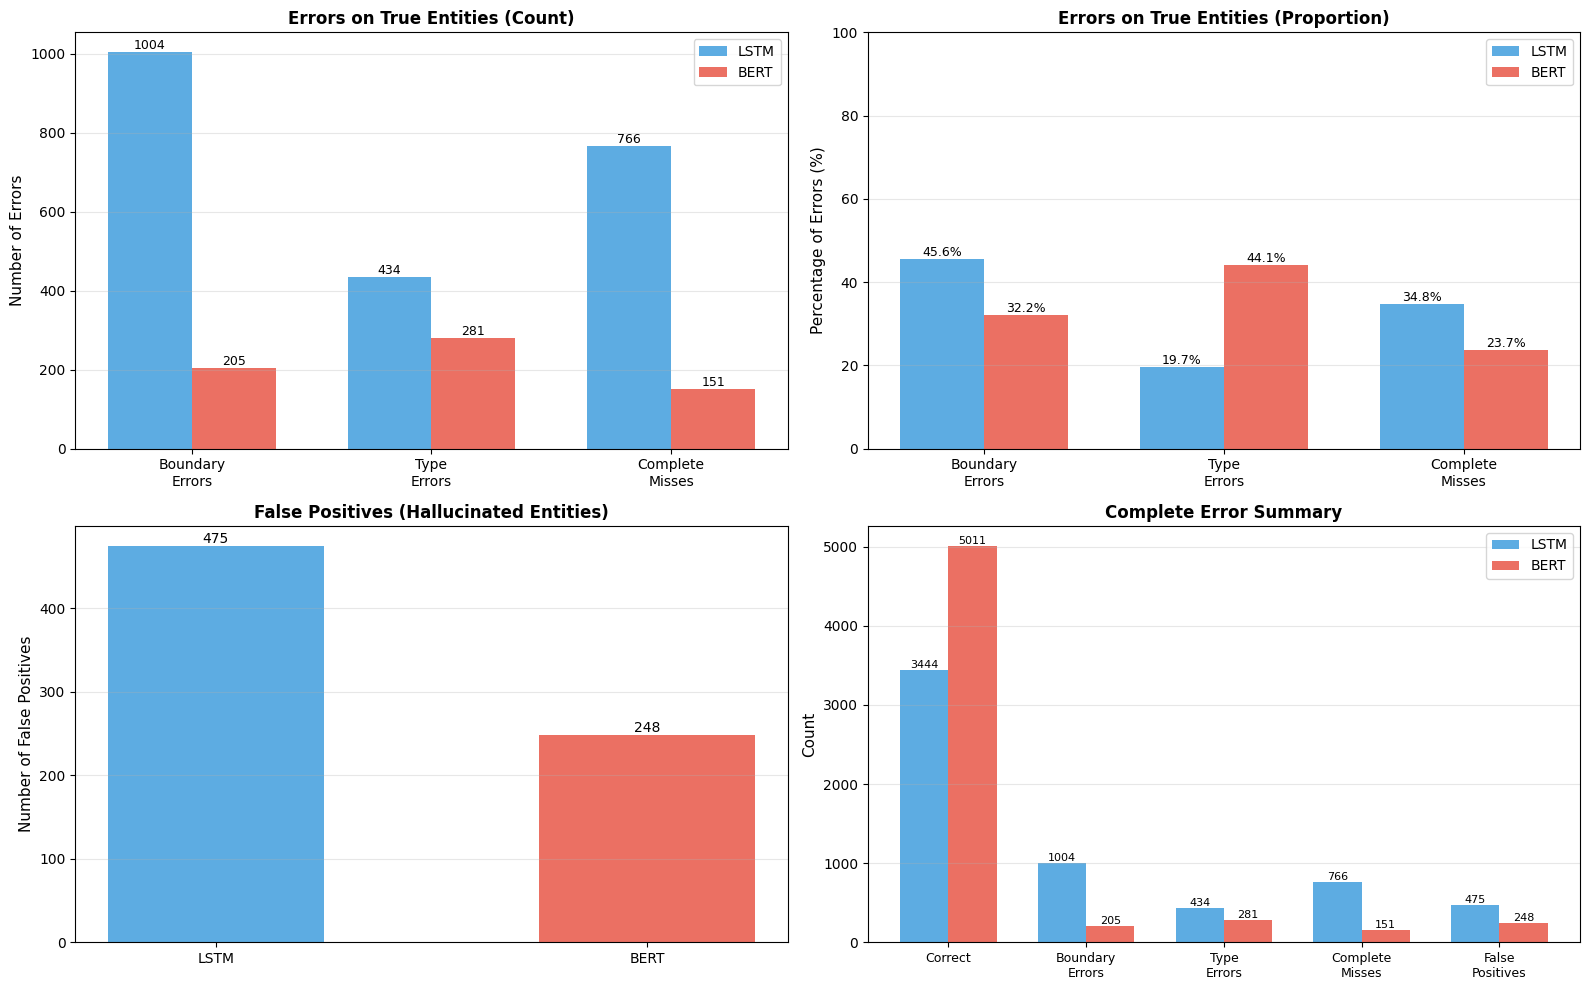

In [81]:
def analyze_errors(true_seqs, pred_seqs, model_name):    
    # Error categories
    boundary_errors = 0  # Right type, wrong boundaries
    type_errors = 0  # Right span, wrong type
    complete_misses = 0  # Entity in true but not in pred
    false_positives = 0  # Entity in pred but not in true
    
    total_entities = 0
    correct_entities = 0
    
    for true_seq, pred_seq in zip(true_seqs, pred_seqs):
        true_entities = extract_entities(true_seq)
        pred_entities = extract_entities(pred_seq)
        
        total_entities += len(true_entities)
        
        for true_entity in true_entities:
            true_type, true_start, true_end = true_entity
            
            # Check if this entity was predicted correctly
            if true_entity in pred_entities:
                correct_entities += 1
            else:
                # Check what kind of error occurred
                found_overlap = False
                
                for pred_entity in pred_entities:
                    pred_type, pred_start, pred_end = pred_entity
                    
                    # Check for boundary errors (same type, overlapping span)
                    if pred_type == true_type:
                        if (pred_start < true_end and pred_end > true_start):  # Overlapping
                            boundary_errors += 1
                            found_overlap = True
                            break
                    
                    # Check for type errors (same span, different type)
                    elif pred_start == true_start and pred_end == true_end:
                        type_errors += 1
                        found_overlap = True
                        break
                
                # If no overlap found, it's a complete miss
                if not found_overlap:
                    complete_misses += 1
        
        # Count false positives (predicted entities that don't match any true entity)
        for pred_entity in pred_entities:
            if pred_entity not in true_entities:
                pred_type, pred_start, pred_end = pred_entity
                # Check if it overlaps with any true entity (if so, already counted above)
                is_overlap = False
                for true_entity in true_entities:
                    true_type, true_start, true_end = true_entity
                    if pred_start < true_end and pred_end > true_start:
                        is_overlap = True
                        break
                if not is_overlap:
                    false_positives += 1
    
    # Calculate total errors
    total_errors = total_entities - correct_entities
    
    return {
        'boundary_errors': boundary_errors,
        'type_errors': type_errors,
        'complete_misses': complete_misses,
        'false_positives': false_positives,
        'total_errors': total_errors,
        'correct_entities': correct_entities,
        'total_entities': total_entities
    }

# Analyze errors for both models
lstm_errors = analyze_errors(lstm_true_seqs, lstm_pred_seqs, "LSTM")
bert_errors = analyze_errors(bert_true_seqs, bert_pred_seqs, "BERT")

# Visualize error distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Chart 1: Error counts on true entities (excludes false positives)
ax1 = axes[0, 0]
error_types_true = ['Boundary\nErrors', 'Type\nErrors', 'Complete\nMisses']
lstm_error_counts = [
    lstm_errors['boundary_errors'], 
    lstm_errors['type_errors'], 
    lstm_errors['complete_misses']
]
bert_error_counts = [
    bert_errors['boundary_errors'], 
    bert_errors['type_errors'], 
    bert_errors['complete_misses']
]

x = np.arange(len(error_types_true))
width = 0.35

bars1 = ax1.bar(x - width/2, lstm_error_counts, width, label='LSTM', color='#3498db', alpha=0.8)
bars2 = ax1.bar(x + width/2, bert_error_counts, width, label='BERT', color='#e74c3c', alpha=0.8)

ax1.set_ylabel('Number of Errors', fontsize=11)
ax1.set_title('Errors on True Entities (Count)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(error_types_true, fontsize=10)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
               f'{int(height)}',
               ha='center', va='bottom', fontsize=9)

# Chart 2: Error proportions on true entities (percentages add to 100%)
ax2 = axes[0, 1]
lstm_total = lstm_errors['total_errors']
bert_total = bert_errors['total_errors']

lstm_props = [e/lstm_total*100 for e in lstm_error_counts]
bert_props = [e/bert_total*100 for e in bert_error_counts]

bars3 = ax2.bar(x - width/2, lstm_props, width, label='LSTM', color='#3498db', alpha=0.8)
bars4 = ax2.bar(x + width/2, bert_props, width, label='BERT', color='#e74c3c', alpha=0.8)

ax2.set_ylabel('Percentage of Errors (%)', fontsize=11)
ax2.set_title('Errors on True Entities (Proportion)', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(error_types_true, fontsize=10)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 100)

for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}%',
               ha='center', va='bottom', fontsize=9)

# Chart 3: False positives comparison
ax3 = axes[1, 0]
models = ['LSTM', 'BERT']
fp_counts = [lstm_errors['false_positives'], bert_errors['false_positives']]

bars5 = ax3.bar(models, fp_counts, color=['#3498db', '#e74c3c'], alpha=0.8, width=0.5)
ax3.set_ylabel('Number of False Positives', fontsize=11)
ax3.set_title('False Positives (Hallucinated Entities)', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

for bar in bars5:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
           f'{int(height)}',
           ha='center', va='bottom', fontsize=10)

# Chart 4: Summary comparison
ax4 = axes[1, 1]
summary_categories = ['Correct', 'Boundary\nErrors', 'Type\nErrors', 'Complete\nMisses', 'False\nPositives']
lstm_summary = [
    lstm_errors['correct_entities'],
    lstm_errors['boundary_errors'],
    lstm_errors['type_errors'],
    lstm_errors['complete_misses'],
    lstm_errors['false_positives']
]
bert_summary = [
    bert_errors['correct_entities'],
    bert_errors['boundary_errors'],
    bert_errors['type_errors'],
    bert_errors['complete_misses'],
    bert_errors['false_positives']
]

x_summary = np.arange(len(summary_categories))
bars6 = ax4.bar(x_summary - width/2, lstm_summary, width, label='LSTM', color='#3498db', alpha=0.8)
bars7 = ax4.bar(x_summary + width/2, bert_summary, width, label='BERT', color='#e74c3c', alpha=0.8)

ax4.set_ylabel('Count', fontsize=11)
ax4.set_title('Complete Error Summary', fontsize=12, fontweight='bold')
ax4.set_xticks(x_summary)
ax4.set_xticklabels(summary_categories, fontsize=9)
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3)

for bars in [bars6, bars7]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
               f'{int(height)}',
               ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

The top row of the plot shows that LSTM has a lot of boundary errors and complete misses compared to BERT. Relatively, BERT makes a lot of mistakes for the type errors, which is the easiest task for LSTM. Boundary errors are quite common for both models (relatively), showing that determining when an entity begins or ends is a difficult task for them. Additionally we see that LSTM identifies almost twice as much false positives as BERT, while at the same time having a lot more complete misses. LSTM struggles to find the right entities, as also revealed by the statistics earlier.

### 3. Entity Length Analysis

I now investigate whether model performance varies with entity length. This can reveal whether models struggle more with longer, multi-token entities or shorter, single-token ones. Below is a code that extracts the length of the entities and determines if they were correctly predicted.

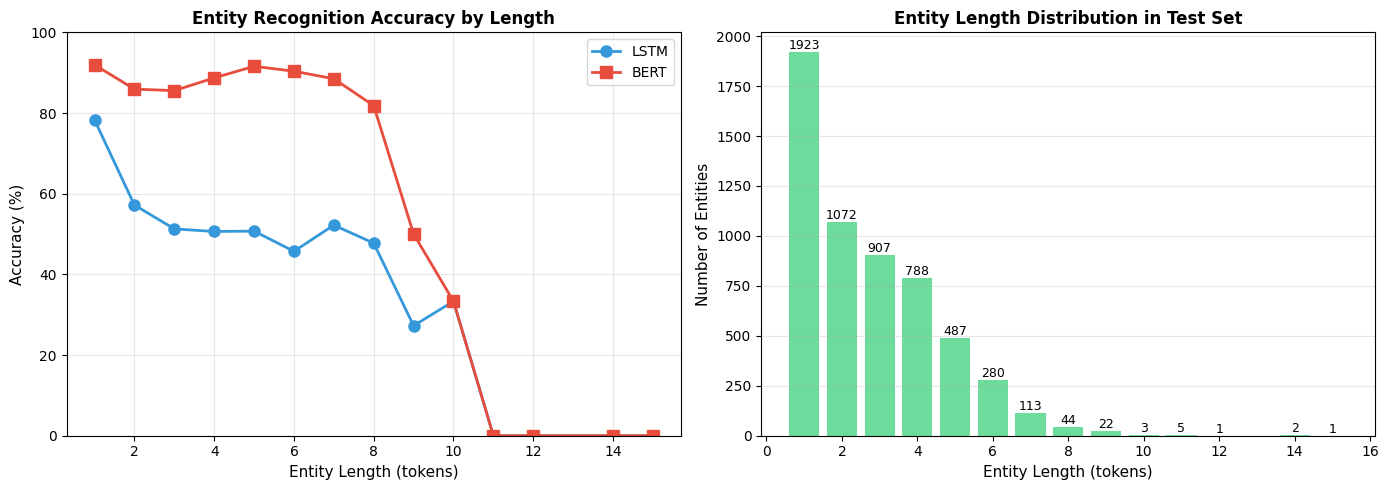

In [82]:
def analyze_by_entity_length(true_seqs, pred_seqs):
    length_stats = {}
    
    for true_seq, pred_seq in zip(true_seqs, pred_seqs):
        true_entities = extract_entities(true_seq)
        pred_entities = extract_entities(pred_seq)
        
        for true_entity in true_entities:
            _, start, end = true_entity
            length = end - start
            stats = length_stats.setdefault(length, {'total': 0, 'correct': 0})
            stats['total'] += 1
            if true_entity in pred_entities:
                stats['correct'] += 1

    lengths = sorted(length_stats.keys())
    accuracies = [length_stats[l]['correct'] / length_stats[l]['total'] for l in lengths]
    counts = [length_stats[l]['total'] for l in lengths]
    return lengths, accuracies, counts

# Analyze both models
lstm_lengths, lstm_accs, lstm_counts = analyze_by_entity_length(lstm_true_seqs, lstm_pred_seqs)
bert_lengths, bert_accs, bert_counts = analyze_by_entity_length(bert_true_seqs, bert_pred_seqs)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(lstm_lengths, [acc * 100 for acc in lstm_accs], 'o-', label='LSTM', color='#3498db', linewidth=2, markersize=8)
ax1.plot(bert_lengths, [acc * 100 for acc in bert_accs], 's-', label='BERT', color='#e74c3c', linewidth=2, markersize=8)
ax1.set_xlabel('Entity Length (tokens)', fontsize=11)
ax1.set_ylabel('Accuracy (%)', fontsize=11)
ax1.set_title('Entity Recognition Accuracy by Length', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 100)

ax2.bar(lstm_lengths, lstm_counts, alpha=0.7, label='Entity Count', color='#2ecc71')
ax2.set_xlabel('Entity Length (tokens)', fontsize=11)
ax2.set_ylabel('Number of Entities', fontsize=11)
ax2.set_title('Entity Length Distribution in Test Set', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for length, count in zip(lstm_lengths, lstm_counts):
    ax2.text(length, count, str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

The entity length analysis shows that most entities in the dataset are short (1-4 tokens), and both models perform best on these short entities. Performance tends to decrease for longer entities, which makes sense as longer entities have more opportunities for boundary errors. BERT maintains its performance advantage consistently across more lengths than LSTM, suggesting that its contextual understanding helps with both short and long entities. We also observe that there are entities with length more than 10, which is probably a result due the fact that we have applied subword tokenization making the entities longer in terms of tokens. Bothe models struggled to identify entities with length more than 8.

## Conclusion

This project successfully developed and compared two Named Entity Recognition systems on the CoNLL-03 dataset: an LSTM-based tagger trained from scratch and a fine-tuned DistilBERT model. The evaluation revealed that BERT substantially outperforms LSTM across all entity-level metrics, achieving 75% precision, 78% recall, and 76% F1-score (macro average) compared to LSTM's 56%, 68%, and 61% respectively.

The error analysis demonstrates that both models' struggle with different types of errors and that they also have a significant amount of false positives. The entity length analysis reveals that performance generally decreases for longer entities, though BERT maintains a more consistent advantage across entity lengths. While subword tokenization inflates entity lengths compared to word-level analysis, the core finding remains: BERT's contextual understanding provides substantial benefits for NER, validating the effectiveness of transfer learning for this task.